##### Now that we've merged the datasets into to concrete and final non-processed data set, its time to analyse each attribute and feel the story its trying to say.

In [2]:
import pandas as pd

In [3]:
pathA = 'data\interim\merged_setA.csv'
dfA = pd.read_csv(pathA)

In [4]:
dfA

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001.psv
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001.psv
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001.psv
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001.psv
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001.psv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790210,88.0,98.0,NaN,135.0,81.00,64.0,16.0,NaN,NaN,NaN,...,NaN,NaN,62.29,1,NaN,NaN,-0.03,31,1,p020643.psv
790211,96.0,98.0,38.72,174.0,97.00,72.0,16.0,NaN,2.0,NaN,...,NaN,NaN,62.29,1,NaN,NaN,-0.03,32,1,p020643.psv
790212,140.0,97.0,NaN,133.0,81.50,62.5,16.0,NaN,NaN,NaN,...,NaN,NaN,62.29,1,NaN,NaN,-0.03,33,1,p020643.psv
790213,120.0,96.0,NaN,154.0,118.00,105.0,16.0,NaN,NaN,NaN,...,NaN,NaN,62.29,1,NaN,NaN,-0.03,34,1,p020643.psv


In [5]:
# 1. HR – Heart Rate (beats per minute).
# 2. O2Sat – Oxygen saturation in the blood (percentage of hemoglobin bound with oxygen).
# 3. Temp – Body temperature.
# 4. SBP – Systolic Blood Pressure (top number in BP, pressure when the heart contracts).
# 5. MAP – Mean Arterial Pressure (average blood pressure over one cardiac cycle).
# 6. DBP – Diastolic Blood Pressure (bottom number in BP, pressure when the heart relaxes).
# 7. Resp – Respiratory rate (breaths per minute).
# 8. EtCO2 – End-tidal CO₂, carbon dioxide level at the end of exhalation (from capnography).
# 9. BaseExcess – Base excess in blood; indicates metabolic component of acid–base balance.
# 10. HCO3 – Bicarbonate level in blood (part of acid–base balance).
# 11. FiO2 – Fraction of inspired oxygen; the percentage of oxygen the patient is receiving.
# 12. pH – Acidity/alkalinity of blood.
# 13. PaCO2 – Partial pressure of carbon dioxide in arterial blood.
# 14. SaO2 – Arterial oxygen saturation (measured from arterial blood gas).
# 15. AST – Aspartate Aminotransferase, a liver enzyme (also in muscle).
# 16. BUN– Blood Urea Nitrogen, marker of kidney function and protein metabolism.
# 17. Alkalinephos – Alkaline Phosphatase, an enzyme related to liver and bile ducts (and bone).
# 18. Calcium – Blood calcium level.
# 19. Chloride – Blood chloride level (an important electrolyte).
# 20. Creatinine – Blood creatinine level, key marker of kidney function.
# 21. Bilirubin_direct – Direct (conjugated) bilirubin, related to liver function and bile excretion.
# 22. Glucose – Blood glucose (blood sugar) level.
# 23. Lactate – Blood lactate level; often rises in poor perfusion or shock.
# 24. Magnesium – Blood magnesium level (electrolyte important for neuromuscular function).
# 25. Phosphate – Blood phosphate level.
# 26. Potassium – Blood potassium level (critical electrolyte for heart rhythm).
# 27. Bilirubin_total – Total bilirubin (direct + indirect), another marker of liver function.
# 28. TroponinI – Cardiac troponin I, a marker of heart muscle injury.
# 29. Hct – Hematocrit, proportion of blood volume that is red blood cells.
# 30. Hgb – Hemoglobin concentration, oxygen-carrying protein in red blood cells.
# 31. PTT – Partial Thromboplastin Time, a blood clotting test.
# 32. WBC – White Blood Cell count, marker of immune response/infection.
# 33. Fibrinogen – Fibrinogen level, a protein involved in blood clotting.
# 34. Platelets – Platelet count, cells involved in clotting.
# 35. Age – Patient’s age (likely in years).
# 36. Gender – Patient’s sex/gender (usually encoded as 0/1).
# 37. Unit1 – Indicator for one type of ICU unit (e.g., MICU vs 38. SICU; often a binary flag).
# 39. Unit2 – Indicator for the other ICU unit type (often complementary to Unit1).
# 40. HospAdmTime – Time from hospital admission to ICU admission (often in hours, may be negative if encoded a certain way).
# 41. ICULOS – ICU Length Of Stay in hours since ICU admission.
# 42. SepsisLabel – Target variable; 1 if the patient is considered septic at that hour, 0 otherwise.

#### Let me do some ECG analysis (interesting)

###### Ploting Hourly heart rate of 10 patients (SEPSIS POSITIVE)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import random as rnd

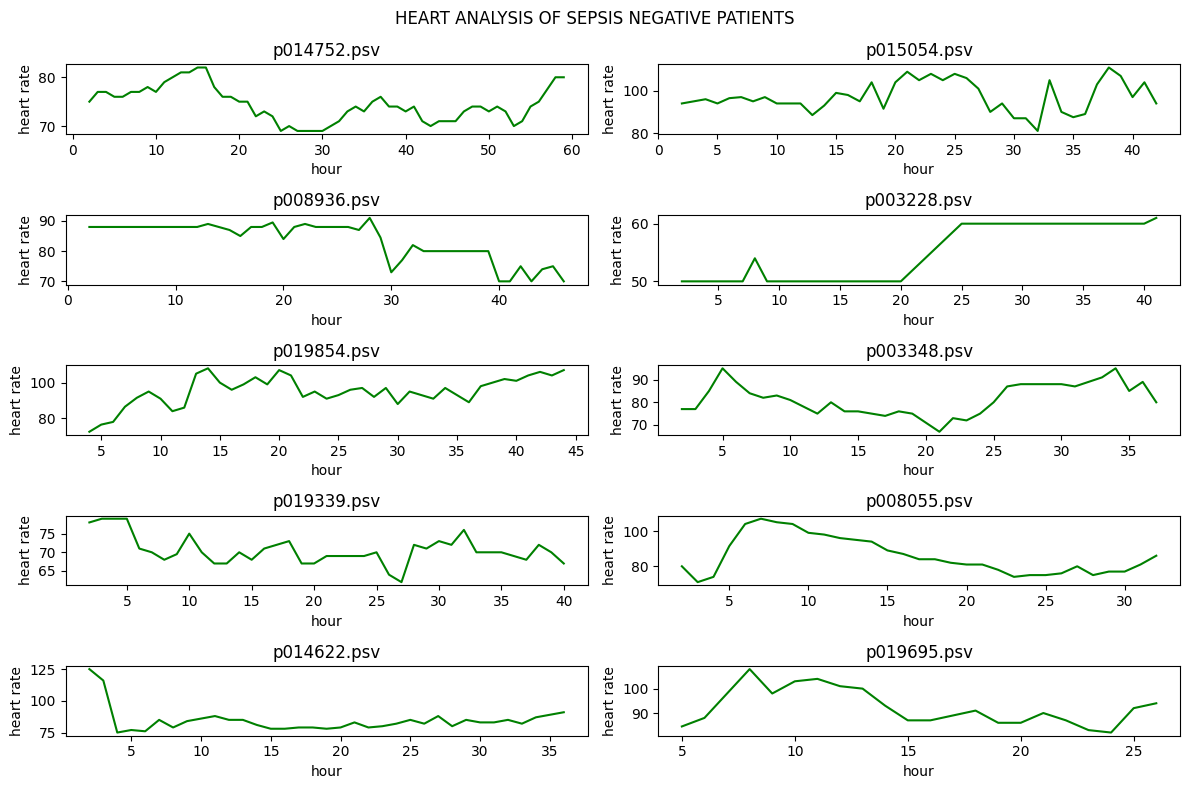

In [7]:
SepsisN = dfA[(dfA['SepsisLabel'] == 0) & (dfA['HR'].notna())]
neg_random_pids = SepsisN['patient_id'].sample(n=10, random_state = 42).tolist()

HR = []
time = []

plt.figure(figsize=(12,8))
plt.suptitle('HEART ANALYSIS OF SEPSIS NEGATIVE PATIENTS')

for i, ids in enumerate(neg_random_pids, 1):
    patient_neg = SepsisN[SepsisN['patient_id']==ids]
    HR = patient_neg['HR']
    time = patient_neg['ICULOS']

    plt.subplot(5, 2, i)
    plt.plot(time, HR, color='green')
    plt.xlabel('hour')
    plt.ylabel('heart rate')
    plt.title(ids)
    plt.tight_layout()

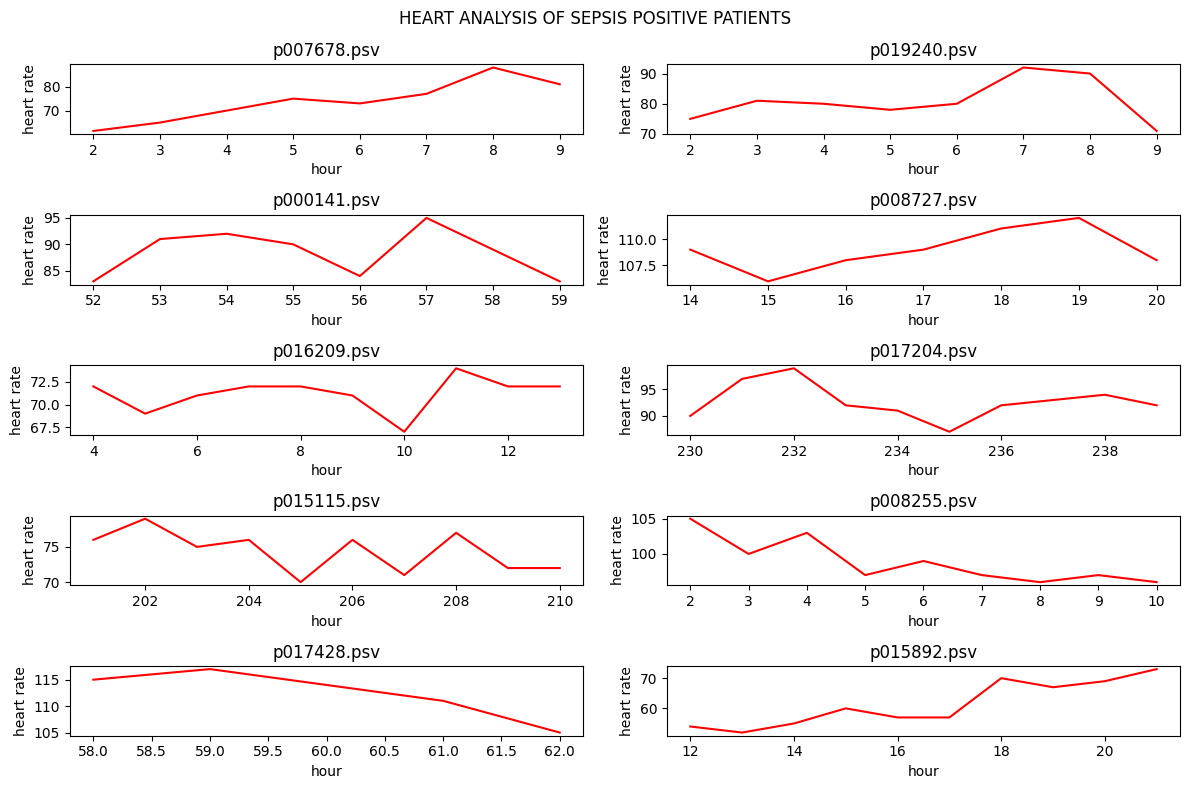

In [8]:

SepsisP = dfA[(dfA['SepsisLabel']==1) & (dfA['HR'].notna())]
pos_random_pids = SepsisP['patient_id'].sample(n=10, random_state = 42).tolist()

HR = []
time = []

plt.figure(figsize=(12,8))
plt.suptitle('HEART ANALYSIS OF SEPSIS POSITIVE PATIENTS')

for i, ids in enumerate(pos_random_pids, 1):
    patient_pos = SepsisP[SepsisP['patient_id']==ids]
    HR = patient_pos['HR']
    time = patient_pos['ICULOS']
    
    plt.subplot(5,2,i)
    plt.plot(time, HR, color = 'red')
    plt.tight_layout()
    plt.xlabel('hour')
    plt.ylabel('heart rate')
    plt.title(ids)
    plt.tight_layout()

#### Let me analyse all the attributes of a Sepsis and Non-Sepsis patient

##### 1. Vital Signs (Primary physiologic vitals)

These are the classic “vitals” tracked continuously or frequently in ICU.

1. **Heart Rate (HR)**  
   - **Reason:** Sepsis often causes **tachycardia** (high HR) due to systemic inflammation, compensatory circulation changes, and stress response. HR trends over time are key for early detection. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC5538252/)

2. **Respiratory Rate (Resp)**  
   - **Reason:** Sepsis triggers **tachypnea** (fast breathing) as part of the body’s stress and compensatory response to acidosis and hypoxia. Elevated Resp is part of SIRS/qSOFA criteria. [aafp](https://www.aafp.org/afp/2020/0401/p409)

3. **Temperature (Temp)**  
   - **Reason:** Sepsis can cause **fever** or **hypothermia**. Both are red flags in the definition of sepsis (abnormal temperature as part of SIRS). [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

4. **Oxygen Saturation (O2Sat)**  
   - **Reason:** Sepsis often leads to **pulmonary dysfunction / ARDS**, causing lower oxygenation. Low O2Sat signals respiratory failure, a key organ dysfunction in sepsis. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

5. **Blood Pressure (multiple measures):**
   - **Mean Arterial Pressure (MAP)**
   - **Systolic Blood Pressure (SBP)** (if present)
   - **Diastolic Blood Pressure (DBP)** (if present)  
   - **Reason:** Sepsis causes **vasodilation and hypotension**, which can progress to **septic shock**. Low BP is a core part of sepsis/septic shock definitions and organ dysfunction. MAP is especially important for perfusion assessment. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

6. **Pain or other subjective vitals** (if present, e.g., Pain)  
   - **Reason:** Less specific for sepsis, but can reflect overall physiologic stress; usually low priority for sepsis EDA unless it’s a key score component.

***

##### 2. Organ Function Markers – Key Systems

These are lab tests or derived scores that reflect how well major organs are functioning. In sepsis, **organ dysfunction** is the defining feature.

###### A. Kidney Function

7. **Creatinine**  
   - **Reason:** Key marker of **kidney dysfunction**. Sepsis can cause acute kidney injury (AKI). Rising creatinine is part of SOFA and KDIGO criteria for organ failure. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

8. **Estimated Creatinine Clearance / eGFR** (if present)  
   - **Reason:** Another estimate of kidney function; useful for tracking renal dysfunction over time.

9. **Urine Output** (if present)  
   - **Reason:** Low urine output is a direct sign of **kidney failure** in sepsis (oliguria). Used in AKI criteria.

***

###### B. Liver Function

10. **Bilirubin (Total)**  
   - **Reason:** Marker of **liver dysfunction / cholestasis**. Elevated bilirubin is part of SOFA for hepatic dysfunction in sepsis. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

11. **AST / ALT** (if present)  
   - **Reason:** Indicate liver cell injury; can rise in sepsis due to hypoperfusion or direct inflammatory effects.

***

###### C. Hematologic / Immune System

12. **White Blood Cell Count (WBC)**  
   - **Reason:** Sepsis often causes **leukocytosis** (high WBC) or **leukopenia** (low WBC); both are part of SIRS criteria. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC5538252/)

13. **Platelets**  
   - **Reason:** Sepsis can cause **thrombocytopenia** (low platelets) due to consumption and coagulopathy. Low platelets are part of SOFA and indicate organ dysfunction. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

14. **Hemoglobin (Hgb) / Hematocrit (Hct)**  
   - **Reason:** Reflect anemia, which can be a marker of chronic disease or severe inflammation; may drop in sepsis due to hemolysis, bleeding, or dilution.

15. **INR / PT / PTT** (if present)  
   - **Reason:** Coagulation markers; sepsis can cause coagulopathy and progress to DIC. Used in severity scoring.

***

###### D. Metabolic / Acid–Base Status

16. **Lactate**  
   - **Reason:** Key marker of **tissue hypoperfusion and anaerobic metabolism**. Elevated lactate is a hallmark of sepsis-related organ dysfunction and is used in guidelines for risk stratification. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

17. **pH** (if present)  
   - **Reason:** Indicates acidosis/alkalosis. Sepsis often causes **metabolic acidosis** (low pH), especially with high lactate.

18. **Serum Bicarbonate (pCO2, pO2, or other blood gas values)** (if present)  
   - **Reason:** Help assess acid–base balance and respiratory compensation; useful for understanding metabolic derangements in sepsis.

***

###### E. Pulmonary / Respiratory Function

19. **pO2 / pCO2** (arterial blood gas) (if present)  
   - **Reason:** Reflect oxygenation and ventilation; sepsis can cause ARDS and respiratory failure.

20. **FiO2** (if present)  
   - **Reason:** Fraction of inspired oxygen; helps assess severity of respiratory support and oxygenation status.

***

###### F. Cardiovascular / Hemodynamic

21. **Cardiac Output / Ejection Fraction** (rare, if present)  
   - **Reason:** Direct measures of cardiac performance; sepsis can cause myocardial dysfunction. Usually less common in standard ICU datasets.

22. **Central Venous Pressure (CVP)** (if present)  
   - **Reason:** Hemodynamic parameter for volume status; less specific but can be used in sepsis management protocols.

***

##### 3. Sepsis Severity / Composite Scores (if present)

These are derived metrics that combine multiple organ function markers.

23. **SOFA Score** (or components)  
   - **Reason:** Summarizes multi‑organ dysfunction (respiratory, coagulation, liver, cardiovascular, CNS, renal). Used extensively in sepsis research and severity assessment. [jamanetwork](https://jamanetwork.com/journals/jama/fullarticle/2492881)

24. **qSOFA criteria** (if derived)  
   - **Reason:** Simplified outpatient/ward version: includes HR, Resp, SBP, and GCS. Directly used for sepsis risk screening. [aafp](https://www.aafp.org/afp/2020/0401/p409)

25. **SIRS Criteria** (if derived)  
   - **Reason:** Classic sepsis criteria: HR, Temp, Resp/WBC. Used historically for sepsis definition. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC5538252/)

***

PRE-PLOTTING

In [9]:
dfA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790215 entries, 0 to 790214
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HR                729026 non-null  float64
 1   O2Sat             695136 non-null  float64
 2   Temp              266901 non-null  float64
 3   SBP               670014 non-null  float64
 4   MAP               709357 non-null  float64
 5   DBP               409918 non-null  float64
 6   Resp              712957 non-null  float64
 7   EtCO2             0 non-null       float64
 8   BaseExcess        82381 non-null   float64
 9   HCO3              63617 non-null   float64
 10  FiO2              112155 non-null  float64
 11  pH                90615 non-null   float64
 12  PaCO2             69288 non-null   float64
 13  SaO2              39160 non-null   float64
 14  AST               11820 non-null   float64
 15  BUN               64476 non-null   float64
 16  Alkalinephos      11

In [20]:
vital_signs = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
metabolic = ['BaseExcess', 'HCO3', 'Lactate']
kidney_function = ['BUN', 'Creatinine', 'Calcium', 'Chloride', 'Magnesium', 'Phosphate', 'Potassium']
hematology = ['Hct', 'Hgb', 'WBC', 'Platelets', 'PTT', 'Fibrinogen']
demographics = ['Age', 'Gender', 'HospAdmTime', 'Unit1', 'Unit2']
cardiac_marker = ['TroponinI']
blood_gas_function = ['FiO2', 'pH', 'PaCO2', 'SaO2']
liver_function = ['AST', 'Alkalinephos', 'Bilirubin_total', 'Bilirubin_direct']
time_label = ['ICULOS', 'SepsisLabel', 'patient_id']

In [12]:
dfA.drop(columns = ['EtCO2'], inplace = True)

KeyError: "['EtCO2'] not found in axis"

In [13]:
dfA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790215 entries, 0 to 790214
Data columns (total 41 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HR                729026 non-null  float64
 1   O2Sat             695136 non-null  float64
 2   Temp              266901 non-null  float64
 3   SBP               670014 non-null  float64
 4   MAP               709357 non-null  float64
 5   DBP               409918 non-null  float64
 6   Resp              712957 non-null  float64
 7   BaseExcess        82381 non-null   float64
 8   HCO3              63617 non-null   float64
 9   FiO2              112155 non-null  float64
 10  pH                90615 non-null   float64
 11  PaCO2             69288 non-null   float64
 12  SaO2              39160 non-null   float64
 13  AST               11820 non-null   float64
 14  BUN               64476 non-null   float64
 15  Alkalinephos      11532 non-null   float64
 16  Calcium           39

The categories: cardiac_marker, blood_gas_function and liver_function can be dropped if the number of data available is less than 50%

#### Checking for Data Density

In [26]:
i = 1
must_keep = vital_signs+metabolic+kidney_function+hematology+demographics
for x in dfA.columns:
    not_null_pct = (dfA[x].count()/len(dfA))*100
    if not_null_pct < 50 and x not in must_keep:
        print(i,x, f'- {not_null_pct:.2f}%')
        i = i+1

1 FiO2 - 14.19%
2 pH - 11.47%
3 PaCO2 - 8.77%
4 SaO2 - 4.96%
5 AST - 1.50%
6 Alkalinephos - 1.46%
7 Bilirubin_direct - 0.15%
8 Glucose - 12.23%
9 Bilirubin_total - 1.23%
10 TroponinI - 0.12%
